# House_price_prediction

### 1405/5/6
### Mohanna Miri 
### Owtana tech _ Second-project

## importing libraries

In [1]:
import pandas as pd
import  numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("housing.csv")

In [3]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
data.dropna(inplace=True)

In [6]:
data.info()

<class 'pandas.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


## train_test_split

In [7]:
from sklearn.model_selection import train_test_split

x=data.drop(["median_house_value"],axis=1)
y=data["median_house_value"]

In [8]:
x_train , x_test , y_train , y_test=train_test_split(x,y, test_size=0.2)

In [9]:
train_data=x_train.join(y_train)

In [10]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
18731,-122.41,40.55,19.0,3753.0,761.0,1952.0,738.0,3.0954,INLAND,86500.0
18994,-121.95,38.43,19.0,3011.0,551.0,1665.0,535.0,5.1534,INLAND,232800.0
8980,-118.41,34.00,46.0,105.0,20.0,69.0,19.0,3.9643,<1H OCEAN,275000.0
8275,-118.16,33.78,15.0,4798.0,1374.0,3087.0,1212.0,2.1270,NEAR OCEAN,163300.0
8441,-118.36,33.91,42.0,1949.0,422.0,1184.0,423.0,4.3333,<1H OCEAN,225600.0
...,...,...,...,...,...,...,...,...,...,...
939,-122.04,37.53,34.0,2316.0,478.0,1524.0,467.0,3.7364,NEAR BAY,190400.0
19454,-120.96,37.66,16.0,4961.0,902.0,2654.0,804.0,4.2823,INLAND,138300.0
13581,-117.28,34.12,36.0,2991.0,822.0,2378.0,751.0,1.3571,INLAND,70600.0
15441,-117.22,33.19,16.0,3004.0,656.0,1948.0,606.0,2.7019,<1H OCEAN,216900.0


#### histogram of train data

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

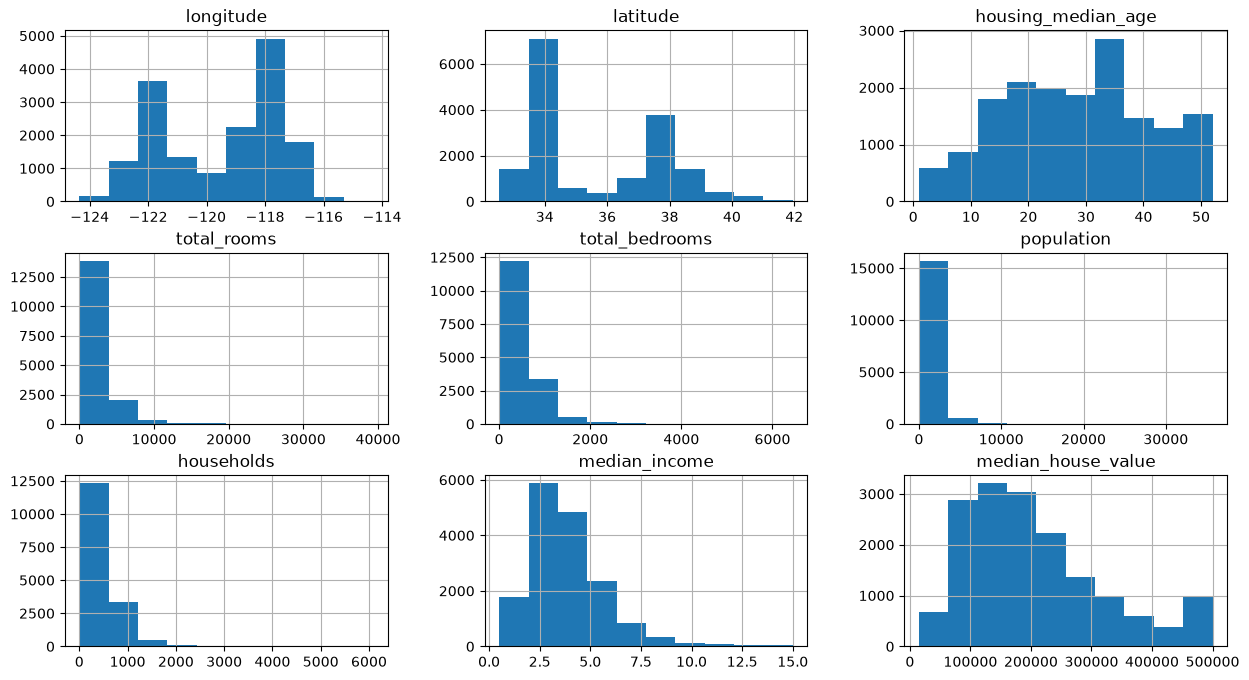

In [11]:
train_data.hist(figsize=(15,8))

### train data with color and 0=<num<=1

<Axes: >

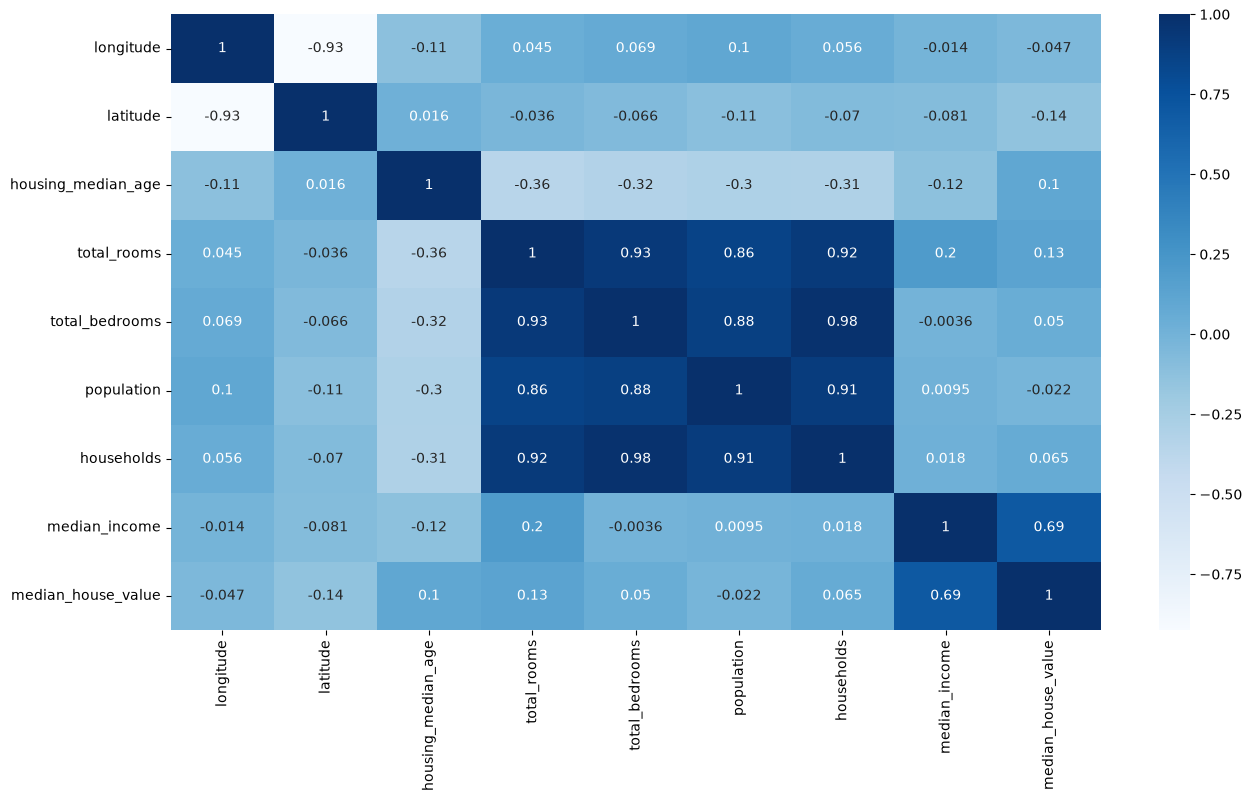

In [12]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True),annot=True,cmap="Blues")

### log for balancing the amounts(Normalize the scale)

In [13]:
train_data["total_rooms"]=np.log(train_data["total_rooms"]+1)
train_data["total_bedrooms"]=np.log(train_data["total_bedrooms"]+1)
train_data["population"]=np.log(train_data["population"]+1)
train_data["households"]=np.log(train_data["households"]+1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

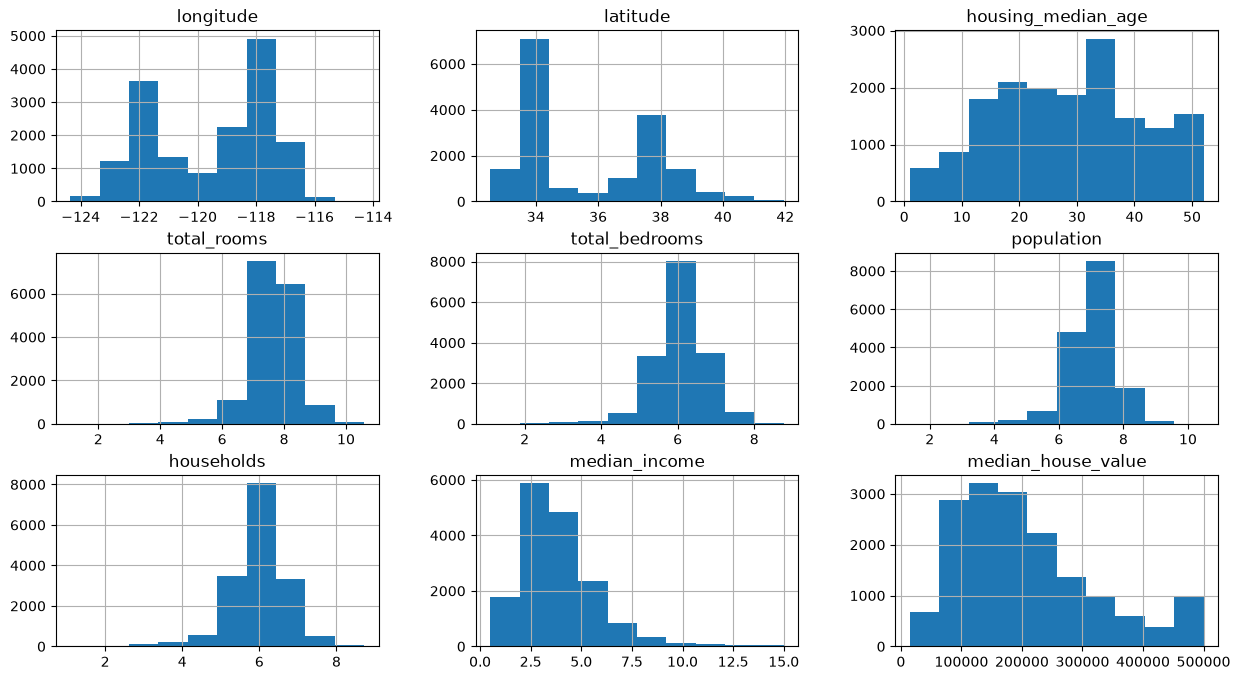

In [14]:
train_data.hist(figsize=(15,8))

In [15]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
18731,-122.41,40.55,19.0,8.230577,6.635947,7.577122,6.605298,3.0954,INLAND,86500.0
18994,-121.95,38.43,19.0,8.010360,6.313548,7.418181,6.284134,5.1534,INLAND,232800.0
8980,-118.41,34.00,46.0,4.663439,3.044522,4.248495,2.995732,3.9643,<1H OCEAN,275000.0
8275,-118.16,33.78,15.0,8.476163,7.226209,8.035279,7.100852,2.1270,NEAR OCEAN,163300.0
8441,-118.36,33.91,42.0,7.575585,6.047372,7.077498,6.049733,4.3333,<1H OCEAN,225600.0
...,...,...,...,...,...,...,...,...,...,...
939,-122.04,37.53,34.0,7.748029,6.171701,7.329750,6.148468,3.7364,NEAR BAY,190400.0
19454,-120.96,37.66,16.0,8.509564,6.805723,7.884200,6.690842,4.2823,INLAND,138300.0
13581,-117.28,34.12,36.0,8.003697,6.712956,7.774436,6.622736,1.3571,INLAND,70600.0
15441,-117.22,33.19,16.0,8.008033,6.487684,7.575072,6.408529,2.7019,<1H OCEAN,216900.0


### Convert ocean_proximity into numerical values by **get_dummies**

In [16]:
train_data=train_data.join(pd.get_dummies(train_data.ocean_proximity)).drop(["ocean_proximity"],axis=1)
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
18731,-122.41,40.55,19.0,8.230577,6.635947,7.577122,6.605298,3.0954,86500.0,False,True,False,False,False
18994,-121.95,38.43,19.0,8.010360,6.313548,7.418181,6.284134,5.1534,232800.0,False,True,False,False,False
8980,-118.41,34.00,46.0,4.663439,3.044522,4.248495,2.995732,3.9643,275000.0,True,False,False,False,False
8275,-118.16,33.78,15.0,8.476163,7.226209,8.035279,7.100852,2.1270,163300.0,False,False,False,False,True
8441,-118.36,33.91,42.0,7.575585,6.047372,7.077498,6.049733,4.3333,225600.0,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,-122.04,37.53,34.0,7.748029,6.171701,7.329750,6.148468,3.7364,190400.0,False,False,False,True,False
19454,-120.96,37.66,16.0,8.509564,6.805723,7.884200,6.690842,4.2823,138300.0,False,True,False,False,False
13581,-117.28,34.12,36.0,8.003697,6.712956,7.774436,6.622736,1.3571,70600.0,False,True,False,False,False
15441,-117.22,33.19,16.0,8.008033,6.487684,7.575072,6.408529,2.7019,216900.0,True,False,False,False,False


### the correlation

<Axes: >

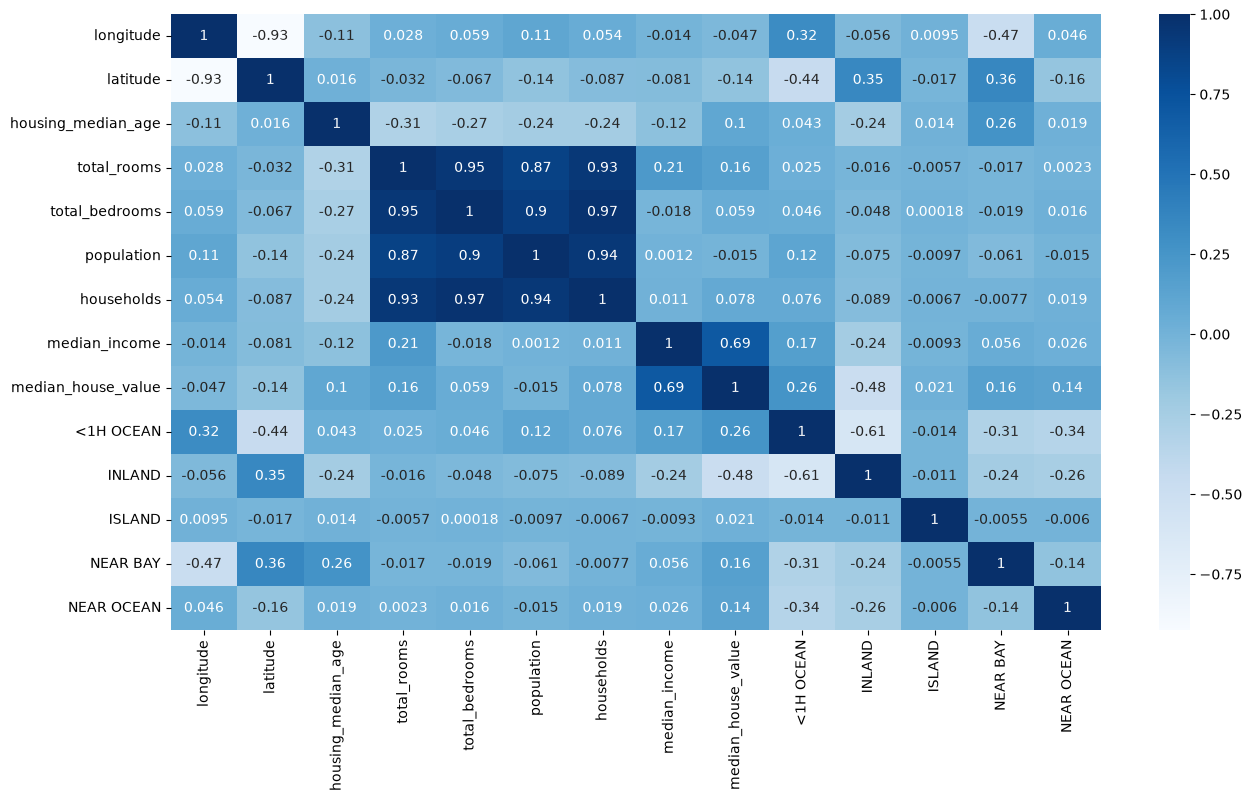

In [17]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True),annot=True,cmap="Blues")

### visualize the correlation

<Axes: xlabel='latitude', ylabel='longitude'>

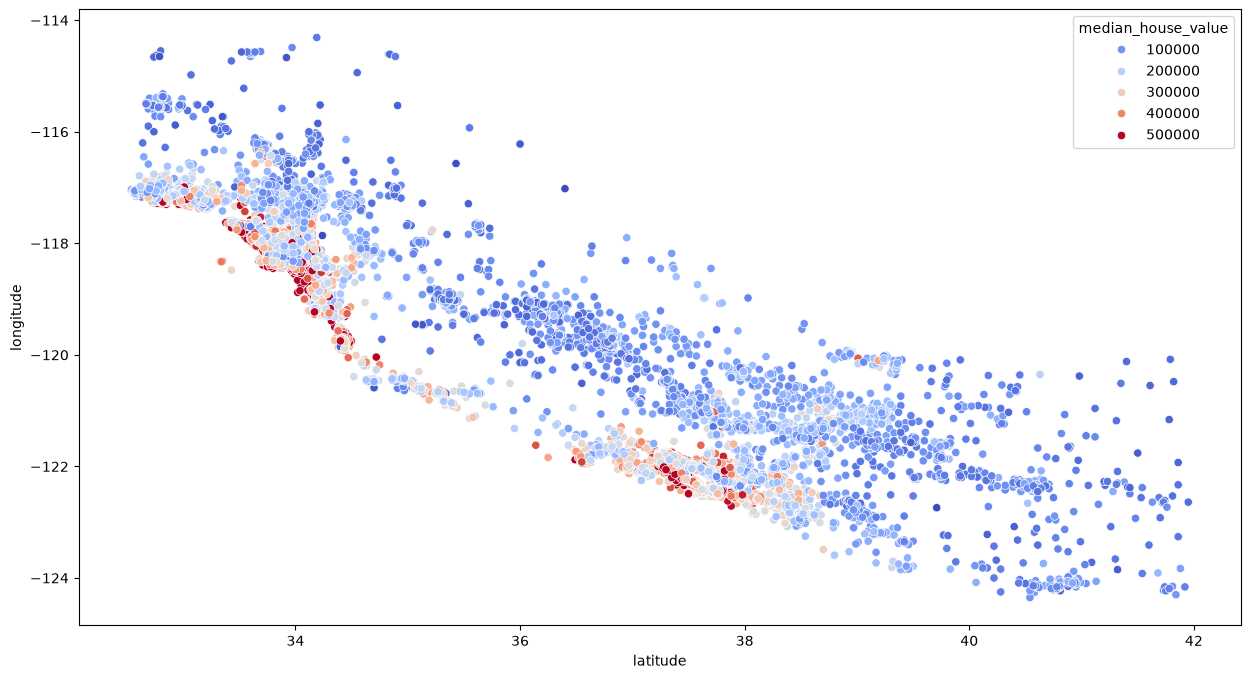

In [18]:
plt.figure(figsize=(15,8))
sns.scatterplot(x="latitude",y="longitude",data=train_data,hue="median_house_value",palette="coolwarm")

### Feature Engineering(combining features)
#### adding new features

In [19]:
train_data["bedroom_ratio"]=train_data["total_bedrooms"]/train_data["total_rooms"]




train_data["household_rooms"]=train_data["total_rooms"]/train_data["households"]


<Axes: >

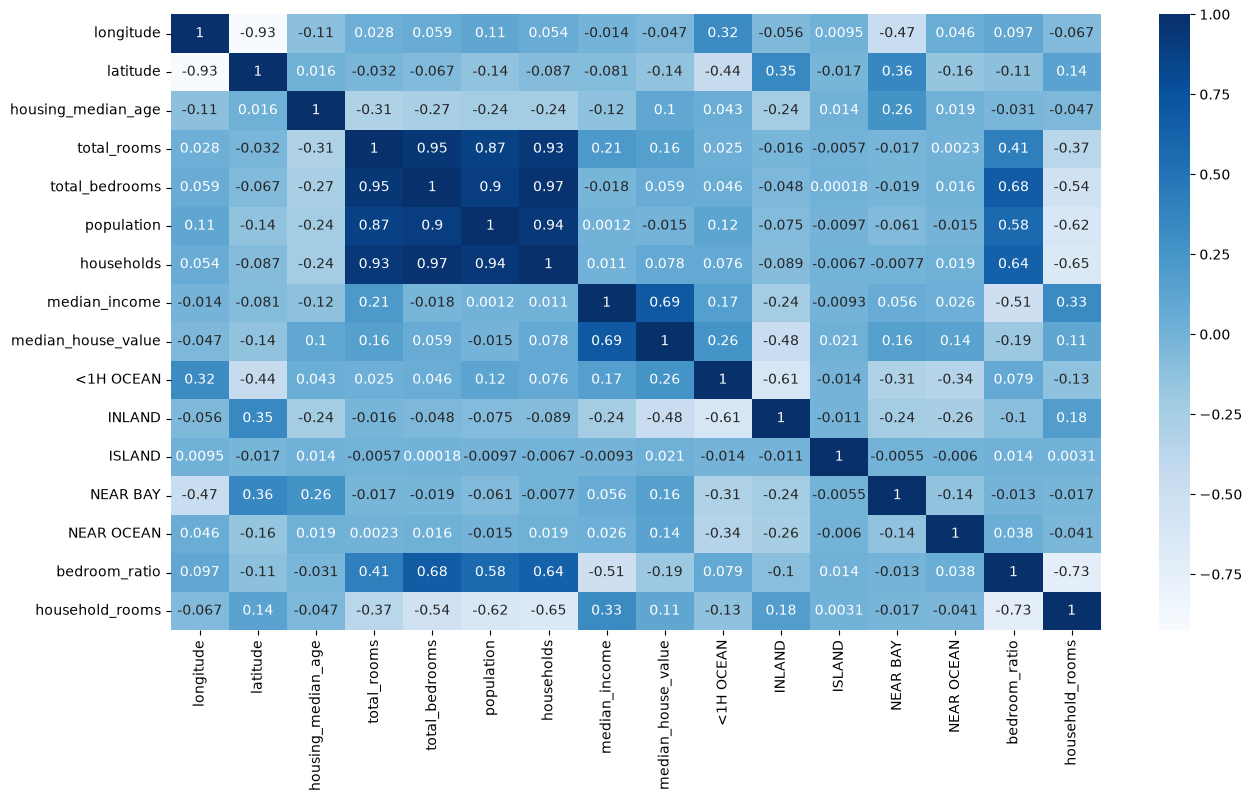

In [20]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True),annot=True,cmap="Blues")

### training the model with reg.fit() and LinearRegression()

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

x_train , y_train= train_data.drop(["median_house_value"],axis=1) , train_data["median_house_value"]
x_train_s = scaler.fit_transform(x_train)

reg=LinearRegression()

reg.fit(x_train_s , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](15,)","[-59744.22,-62095.22, 13576.54,..., 3169.76,-13878.56, -1306.12]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.067e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,15
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](15,)","[279.57,204.1 ,167.64,..., 12.02, 5.37, 0. ]"


## Start the Test process

### Test data(Model for Testing)

In [22]:
test_data=x_test.join(y_test)

test_data["total_rooms"]=np.log(test_data["total_rooms"]+1)
test_data["total_bedrooms"]=np.log(test_data["total_bedrooms"]+1)
test_data["population"]=np.log(test_data["population"]+1)
test_data["households"]=np.log(test_data["households"]+1)

#-------------------------------------------------------------------------------------------------
#------------------------------------------------------------------------------------------------
test_data=test_data.join(pd.get_dummies(test_data.ocean_proximity)).drop(["ocean_proximity"],axis=1)

test_data["bedroom_ratio"]=test_data["total_bedrooms"]/test_data["total_rooms"]
test_data["household_rooms"]=test_data["total_rooms"]/test_data["households"]


In [23]:
x_test , y_test= test_data.drop(["median_house_value"],axis=1) , test_data["median_house_value"]

In [24]:
x_test_s = scaler.transform(x_test)

### Testing the model with reg.score()=R^2
###### for better R^2 --> use scaler.fit_transform


In [25]:
reg.score(x_test_s,y_test)

0.6575194423060087

### Random Forest Model


In [26]:
from sklearn.ensemble import RandomForestRegressor

forest=RandomForestRegressor()

forest.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

forest = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    forest,
    param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(x_train_s, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10], 'min_samples_split': [2, 5], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, defaul

In [39]:
forest = RandomForestRegressor()
forest.fit(x_train_s, y_train)
forest.score(x_test_s,y_test)

0.8016023386830197

In [40]:
best_forest= grid_search.best_estimator_

In [41]:
best_forest.score(x_test_s, y_test)

0.8004066807183194

### LinearRegression Model(MAE,MSE,RMSE,R^2 score)

In [42]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ساخت مدل
lin_reg = LinearRegression()

# آموزش مدل روی داده‌های train
lin_reg.fit(x_train_s, y_train)

# پیش‌بینی روی داده‌ی تست
y_pred_lin = lin_reg.predict(x_test_s)

# محاسبه‌ی معیارها
mae_lin = mean_absolute_error(y_test, y_pred_lin)
mse_lin = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test, y_pred_lin)

# نمایش نتایج
print("Linear Regression:")
print(f"MAE  = {mae_lin:.2f}")
print(f"MSE  = {mse_lin:.2f}")
print(f"RMSE = {rmse_lin:.2f}")
print(f"R2   = {r2_lin:.4f}")

Linear Regression:
MAE  = 48556.93
MSE  = 4653393845.39
RMSE = 68215.79
R2   = 0.6575


### Decision Tree Model (MAE,MSE,RMSE,R^2 score)

In [43]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ساخت مدل Decision Tree
tree_reg = DecisionTreeRegressor(random_state=42)

# آموزش مدل
tree_reg.fit(x_train_s, y_train)

# پیش‌بینی روی داده تست
y_pred_tree = tree_reg.predict(x_test_s)

# محاسبه معیارها
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

# نمایش نتایج
print("Decision Tree:")
print(f"MAE  = {mae_tree:.2f}")
print(f"MSE  = {mse_tree:.2f}")
print(f"RMSE = {rmse_tree:.2f}")
print(f"R2   = {r2_tree:.4f}")

Decision Tree:
MAE  = 45555.34
MSE  = 5251332532.61
RMSE = 72466.08
R2   = 0.6135


### Random Forest Model(MAE,MSE,RMSE,R^2 score)

In [44]:

# پیش‌بینی روی داده تست
best_forest = grid_search.best_estimator_

y_pred_forest = best_forest.predict(x_test_s)
# محاسبه معیارها
mae_forest = mean_absolute_error(y_test, y_pred_forest)
mse_forest = mean_squared_error(y_test, y_pred_forest)
rmse_forest = np.sqrt(mse_forest)
r2_forest = r2_score(y_test, y_pred_forest)

print("Random Forest Results:")
print("----------------------")
print(f"MAE  : {mae_forest:.2f}")
print(f"MSE  : {mse_forest:.2f}")
print(f"RMSE : {rmse_forest:.2f}")
print(f"R²   : {r2_forest:.4f}")

Random Forest Results:
----------------------
MAE  : 33550.87
MSE  : 2711938831.74
RMSE : 52076.28
R²   : 0.8004


### DataFrame for comparison

In [45]:
import pandas as pd

results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "MAE": [mae_lin, mae_tree, mae_forest],
    "MSE": [mse_lin, mse_tree, mse_forest],
    "RMSE": [rmse_lin, rmse_tree, rmse_forest],
    "R2 Score": [r2_lin, r2_tree, r2_forest]
}).set_index("Model")

print(results_df)

                            MAE           MSE          RMSE  R2 Score
Model                                                                
Linear Regression  48556.934118  4.653394e+09  68215.788828  0.657519
Decision Tree      45555.341081  5.251333e+09  72466.078496  0.613512
Random Forest      33550.873441  2.711939e+09  52076.278974  0.800407


### Bar Chart for comparison

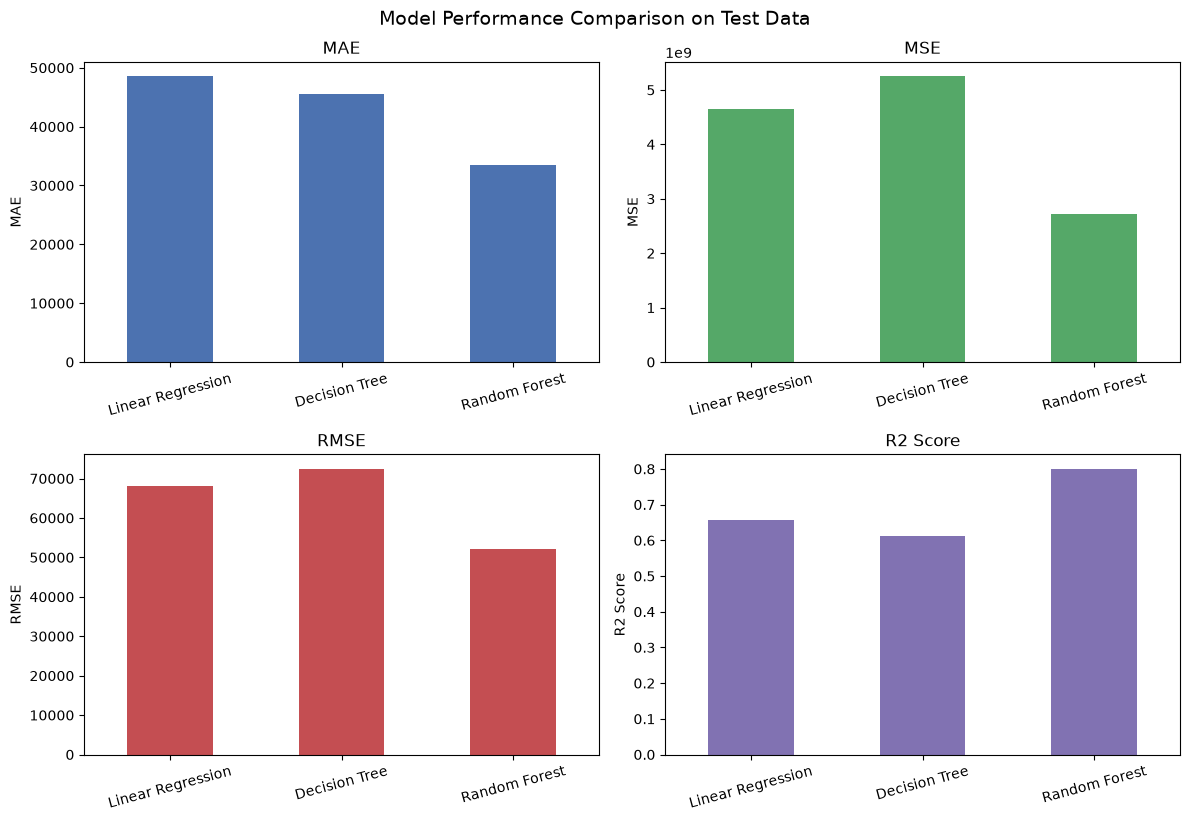

In [47]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics = ["MAE", "MSE", "RMSE", "R2 Score"]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

for ax, metric, color in zip(axes.flatten(), metrics, colors):
    results_df[metric].plot(kind="bar", ax=ax, color=color)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.suptitle("Model Performance Comparison on Test Data", y=1.02, fontsize=14)
plt.show()